In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
)


In [3]:
file_path = Path(
    "/home/divas/ml/CI-diagnosis-agent/data/benchmark_data/final_test_cases.jsonl"
)

df = pd.read_json(file_path, lines=True)
df.head()


,test_id,split,scenario_description,ground_truth,evidence,scenario_optimal_action,generation_metadata,expected_agent_action,hard_case_tags
0,easy_000001,medium,The event-bus CI pipeline failed during the De...,"{'state': 'S4', 'failure_mechanism': 'import_o...","{'E1': {'outcome': 'A', 'observation': 'The de...","{'optimal_action': 'fix_code', 'ground_action'...","{'generation_method': 'scenario_renderer', 'di...",Fix lint,NaN
1,easy_000002,easy,The analytics-platform repository's Continuous...,"{'state': 'S1', 'failure_mechanism': 'logic_bug'}","{'E1': {'outcome': 'C', 'observation': 'The te...","{'optimal_action': 'fix_code', 'ground_action'...","{'generation_method': 'scenario_renderer', 'di...",Escalate,NaN
2,easy_000003,easy,A pull request in the ml-model-serving project...,"{'state': 'S3', 'failure_mechanism': 'dependen...","{'E1': {'outcome': 'A', 'observation': 'The de...","{'optimal_action': 'resolve_dependency', 'grou...","{'generation_method': 'scenario_renderer', 'di...",Fix dependency,NaN
3,easy_000004,easy,The api-gateway repository's Smoke Tests workf...,"{'state': 'S4', 'failure_mechanism': 'lint_vio...","{'E1': {'outcome': 'D', 'observation': 'The st...","{'optimal_action': 'fix_code', 'ground_action'...","{'generation_method': 'scenario_renderer', 'di...",Fix lint,NaN
4,easy_000005,easy,The user-service CI pipeline failed during the...,"{'state': 'S5', 'failure_mechanism': 'mock_fai...","{'E1': {'outcome': 'C', 'observation': 'The te...","{'optimal_action': 'investigate_tests', 'groun...","{'generation_method': 'scenario_renderer', 'di...",Escalate,NaN


In [4]:
def process_row(row):
    gt = row.get("ground_truth") or {}
    ev = row.get("evidence") or {}
    soa = row.get("scenario_optimal_action") or {}

    processed = {
        "test_id": row.get("test_id"),
        "split": row.get("split"),
        "scenario_description": row.get("scenario_description"),
        "ground_truth": (
            gt.get("state") if isinstance(gt, dict) else None
        ),  # Extracts state (e.g. S4, S1)
        # Evidence outcomes
        "E1_outcome": (
            ev.get("E1", {}).get("outcome") if isinstance(ev, dict) else None
        ),
        "E2_outcome": (
            ev.get("E2", {}).get("outcome") if isinstance(ev, dict) else None
        ),
        "E3_outcome": (
            ev.get("E3", {}).get("outcome") if isinstance(ev, dict) else None
        ),
        "E4_outcome": (
            ev.get("E4", {}).get("outcome") if isinstance(ev, dict) else None
        ),
        # Evidence observations
        "E1_observation": (
            ev.get("E1", {}).get("observation") if isinstance(ev, dict) else None
        ),
        "E2_observation": (
            ev.get("E2", {}).get("observation") if isinstance(ev, dict) else None
        ),
        "E3_observation": (
            ev.get("E3", {}).get("observation") if isinstance(ev, dict) else None
        ),
        "E4_observation": (
            ev.get("E4", {}).get("observation") if isinstance(ev, dict) else None
        ),
        # Optimal scenario action fields
        "optimal_scenario_action": (
            soa.get("optimal_action") if isinstance(soa, dict) else None
        ),
        "ground_action": (
            soa.get("ground_action") if isinstance(soa, dict) else None
        ),
        "description": (
            soa.get("description") if isinstance(soa, dict) else None
        ),
    }

    return pd.Series(processed)


# Apply the processing across all rows
df = df.apply(process_row, axis=1)

# View the formatted DataFrame
df.head()

,test_id,split,scenario_description,ground_truth,E1_outcome,E2_outcome,E3_outcome,E4_outcome,E1_observation,E2_observation,E3_observation,E4_observation,optimal_scenario_action,ground_action,description
0,easy_000001,medium,The event-bus CI pipeline failed during the De...,S4,A,src,pass_on_rerun,not_reproducible_locally,The dependency installation step was the first...,The eventual successful repair modified applic...,Rerunning the exact same commit on CI resulted...,The failure could not be reproduced in a local...,fix_code,Fix Lint,The failure is a static-analysis violation tha...
1,easy_000002,easy,The analytics-platform repository's Continuous...,S1,C,src,fail_on_rerun,reproducible_locally,The test execution step was the first failed s...,The eventual successful repair modified applic...,Rerunning the exact same commit on CI produced...,The developer reproduced the same failure in t...,fix_code,Escalate,The failure originates from a defect in the ap...
2,easy_000003,easy,A pull request in the ml-model-serving project...,S3,A,config,fail_on_rerun,not_reproducible_locally,The dependency installation step was the first...,The eventual successful repair modified projec...,Rerunning the exact same commit on CI produced...,The failure could not be reproduced in a local...,resolve_dependency,Fix Dependency,The failure is caused by a dependency manageme...
3,easy_000004,easy,The api-gateway repository's Smoke Tests workf...,S4,D,src,fail_on_rerun,reproducible_locally,The static analysis or quality checks step was...,The eventual successful repair modified applic...,Rerunning the exact same commit on CI produced...,The developer reproduced the same failure in t...,fix_code,Fix Lint,The failure is a static-analysis violation tha...
4,easy_000005,easy,The user-service CI pipeline failed during the...,S5,C,test,fail_on_rerun,reproducible_locally,The test execution step was the first failed s...,The eventual successful repair modified test f...,Rerunning the exact same commit on CI produced...,The developer reproduced the same failure in t...,investigate_tests,Escalate,The failure is a test execution problem that r...


### 1.Data Analysis

In [5]:
df['ground_truth'].value_counts(normalize = True)

ground_truth
S3    0.222222
S5    0.189542
S4    0.183007
S1    0.143791
S7    0.104575
S6    0.084967
S2    0.071895
Name: proportion, dtype: float64

In [6]:
df['ground_action'].value_counts(normalize = True)

ground_action
Escalate          0.500000
Fix Dependency    0.296053
Fix Lint          0.203947
Name: proportion, dtype: float64

In [7]:
df.shape

(153, 15)

### 1. V0 dump baseline

Always predict **Escalate** (majority `ground_action`). One unlabeled row is dropped before scoring.


In [13]:
import matplotlib.pyplot as plt
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
)

V0 dump baseline: always Escalate
Evaluated rows: 152 / 153
Accuracy:  0.5000
Precision (macro): 0.1667
Recall (macro):    0.3333

                precision    recall  f1-score   support

      Escalate       0.50      1.00      0.67        76
Fix Dependency       0.00      0.00      0.00        45
      Fix Lint       0.00      0.00      0.00        31

      accuracy                           0.50       152
     macro avg       0.17      0.33      0.22       152
  weighted avg       0.25      0.50      0.33       152

Confusion matrix (rows=true, cols=pred):
                Escalate  Fix Dependency  Fix Lint
Escalate              76               0         0
Fix Dependency        45               0         0
Fix Lint              31               0         0


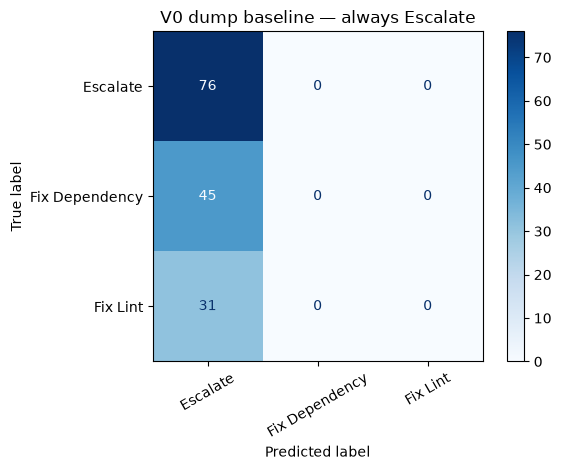

In [14]:
# Always predict Escalate (majority class). Drop the one row with missing ground_action.
ACTION_LABELS = ["Escalate", "Fix Dependency", "Fix Lint"]

eval_df = df.dropna(subset=["ground_action"]).copy()
eval_df["p0_prediction"] = "Escalate"

y_true = eval_df["ground_action"]
y_pred = eval_df["p0_prediction"]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(
    y_true, y_pred, average="macro", labels=ACTION_LABELS, zero_division=0
)
recall = recall_score(
    y_true, y_pred, average="macro", labels=ACTION_LABELS, zero_division=0
)

print("V0 dump baseline: always Escalate")
print(f"Evaluated rows: {len(eval_df)} / {len(df)}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print()
print(classification_report(y_true, y_pred, labels=ACTION_LABELS, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=ACTION_LABELS)
print("Confusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(cm, index=ACTION_LABELS, columns=ACTION_LABELS))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ACTION_LABELS)
disp.plot(cmap="Blues", xticks_rotation=30)
plt.title("V0 dump baseline — always Escalate")
plt.tight_layout()
plt.show()


### 2. V1 Bayesian action policy (decision record §4–§5)

Priors and likelihoods from the record. After each evidence update, act if `P(S1)+P(S2)+P(S4) > 0.60` (fix code → Fix Lint) or `P(S3) > 0.80` (Fix Dependency). Otherwise query the remaining source with highest EIG. If all evidence is used and no threshold is met, escalate.


In [ ]:
eval_df = df.dropna(subset=["ground_action"]).copy()
eval_df["v1_prediction"] = eval_df.apply(run_v1_policy, axis=1)

y_true = eval_df["ground_action"]
y_pred = eval_df["v1_prediction"]

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(
    y_true, y_pred, average="macro", labels=ACTION_LABELS, zero_division=0
)
recall = recall_score(
    y_true, y_pred, average="macro", labels=ACTION_LABELS, zero_division=0
)

print("V1 Bayesian action policy vs ground_action")
print(f"Evaluated rows: {len(eval_df)}")
print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision (macro): {precision:.4f}")
print(f"Recall (macro):    {recall:.4f}")
print()
print("Prediction mix:")
print(eval_df["v1_prediction"].value_counts())
print()
print(classification_report(y_true, y_pred, labels=ACTION_LABELS, zero_division=0))

cm = confusion_matrix(y_true, y_pred, labels=ACTION_LABELS)
print("Confusion matrix (rows=true, cols=pred):")
print(pd.DataFrame(cm, index=ACTION_LABELS, columns=ACTION_LABELS))

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=ACTION_LABELS)
disp.plot(cmap="Blues", xticks_rotation=30)
plt.title("V1 Bayesian action policy vs ground_action")
plt.tight_layout()
plt.show()


NameError: name 'df' is not defined